# Distance Generator

This notebook develops a pipeline for selecting demand regions, warehouses, and suppliers from real-world data and computing the associated distance tables.

### Pipeline overview

| Step | Description | Output |
|------|-------------|--------|
| **1** | Setup and Data Loading | - |
| **2** | Exploratory Data Analysis | - |
| **3** | Compute weight-based demand intensity $I_r$ per region | Normalized intensities $\tilde{I}_r$ |
| **4** | Fit geographic structure via GMM on the unit sphere | Geographic density score $p_{\text{geo}}(r)$ |
| **5** | Sample $n_{\text{regions}}$ synthetic regions | Selected region set $R$ |
| **6** | Select $n_{\text{warehouses}}$ via demand-weighted k-median | Selected warehouse set $W$ |
| **7** | Sample $n_{\text{skus}}$ SKUs and select feasible suppliers | Supplier set $S$, supplier–warehouse distances |
| **8** | Compute and store outbound and inbound distance tables | Distance matrices for the simulator |
| **9** | Testing and Validation | - |


## 1. Setup & Data Loading

### 1.1 Configuration

In [63]:
# CONFIGURATION

# Seed
SEED = 42

# Data path
RAW_DATA_PATH = "../../../data_files/raw"

# Output paths
OUTPUTS_PATH = "outputs/intermediate"
MODELS_PATH = "outputs/generated_models"

# Number of regions, warehouses, and SKUs to select
n_regions = 10
n_warehouses = 10
n_skus = 10

# Earth radius in kilometers
EARTH_RADIUS_KM = 6371.0

### 1.2 Imports & Data Loading

In [64]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.mixture import GaussianMixture
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 100

rng = np.random.default_rng(SEED)

In [65]:
path = Path(RAW_DATA_PATH)  
regions_df = pd.read_csv(path / "02_regions.csv")
warehouses_df = pd.read_csv(path / "01_warehouses.csv")
suppliers_df = pd.read_csv(path / "04_suppliers.csv")
skus_df = pd.read_csv(path / "06_skus.csv")
skus_per_supplier_df = pd.read_csv(path / "07_skus_per_supplier.csv")
orders_df = pd.read_csv(path / "08_orders.csv")
order_sku_demand_df = pd.read_csv(path / "09_order_sku_demand.csv")

print(f"Regions:            {len(regions_df):>6,}")
print(f"Warehouses:         {len(warehouses_df):>6,}")
print(f"Suppliers:          {len(suppliers_df):>6,}")
print(f"SKUs:               {len(skus_df):>6,}")
print(f"SKU–supplier links: {len(skus_per_supplier_df):>6,}")
print(f"Orders:             {len(orders_df):>6,}")
print(f"Order–SKU demand:   {len(order_sku_demand_df):>6,}")

Regions:                57
Warehouses:             24
Suppliers:             572
SKUs:               10,578
SKU–supplier links: 13,024
Orders:             35,562
Order–SKU demand:   258,212


### 1.3 Build SKU weight lookup

Create a mapping from `itemid` to per-unit weight $w_s$ for use in the demand-intensity calculation.

In [66]:
sku_weight_map = skus_df.set_index("itemid")["weight"].to_dict()
print(f"SKU weight map: {len(sku_weight_map)} entries")
print(f"  Example: SKU_01664 -> {sku_weight_map.get('SKU_01664', 'N/A'):.4f} kg")

SKU weight map: 10578 entries
  Example: SKU_01664 -> 1.4400 kg


### 1.4 Sample SKU indices

We sample `n_skus` SKU indices for use in the supplier selection.

In [67]:
#  SAMPLE SKUS

# Get all available SKU IDs
all_sku_ids = skus_df["itemid"].values

# Safety check
if n_skus > len(all_sku_ids):
    raise ValueError(f"n_skus={n_skus} exceeds available SKUs ({len(all_sku_ids)})")

# Select n_sku indices uniformly at random
selected_sku_indices = rng.choice(len(all_sku_ids), size=n_skus, replace=False)
selected_sku_ids = all_sku_ids[selected_sku_indices]

# Print results
print(f"Selected {len(selected_sku_ids)}.")
print(f"First 10 selected SKU IDs: {selected_sku_ids[:10]}")

Selected 10.
First 10 selected SKU IDs: ['SKU_07382' 'SKU_09129' 'SKU_08741' 'SKU_01268' 'SKU_06283' 'SKU_07935'
 'SKU_06985' 'SKU_02830' 'SKU_08409' 'SKU_06207']


## 2. Exploratory Data Analysis

Before building the generation pipeline, let us understand the geographic distribution of regions, warehouses, and suppliers, and the demand structure.

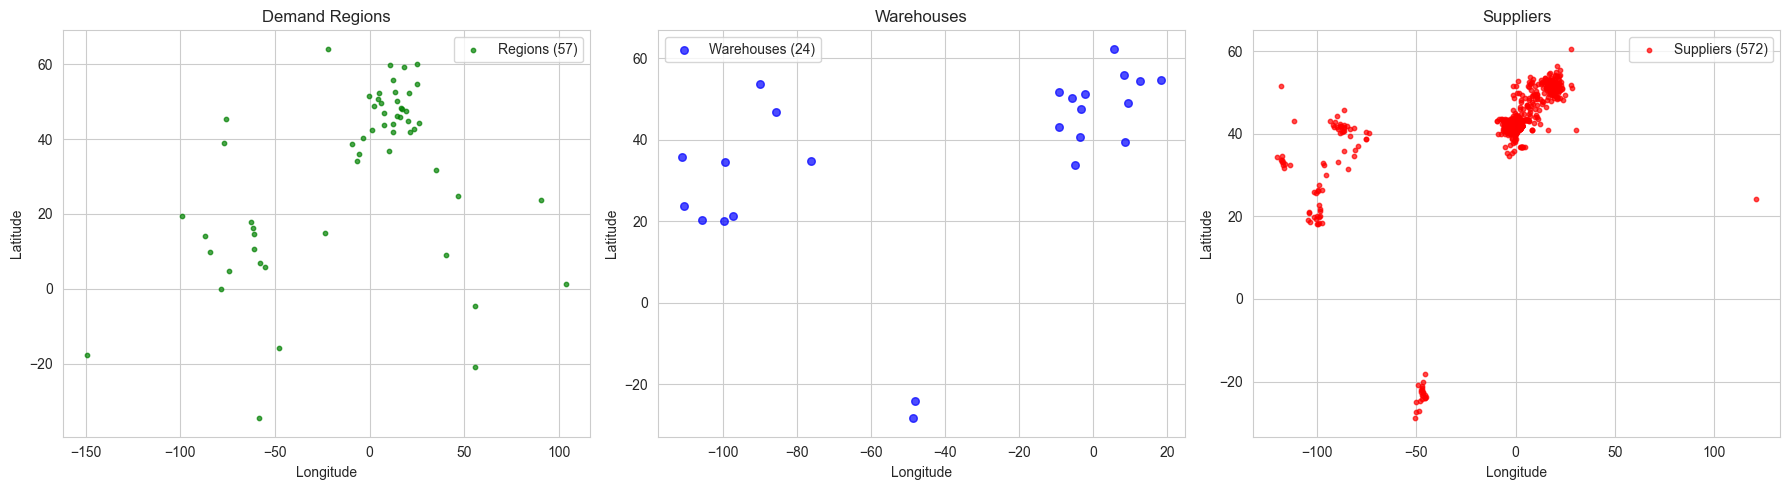

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(regions_df["longitude"], regions_df["latitude"], s=10, alpha=0.7, c="green", label=f"Regions ({len(regions_df)})")
axes[0].set_title("Demand Regions")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
axes[0].legend()

axes[1].scatter(warehouses_df["longitude"], warehouses_df["latitude"], s=30, alpha=0.7, c="blue", label=f"Warehouses ({len(warehouses_df)})")
axes[1].set_title("Warehouses")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].legend()

axes[2].scatter(suppliers_df["longitude"], suppliers_df["latitude"], s=10, alpha=0.7, c="red", label=f"Suppliers ({len(suppliers_df)})")
axes[2].set_title("Suppliers")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Region Intensity (Weight-Based Demand Signal)

We select `n_skus` SKUs uniformly at random. For each region $r$, we compute the average total weight shipped per period for all selected SKUs:

$$I_r = \frac{1}{T} \sum_{t \in T} \left( \sum_{o \in O_r} \sum_{s \in S} q_{o,s} \cdot w_s) \right)$$

where $T$ is the number of distinct time periods (days) in the dataset, $O_r$ is the set of all orders from region $r$, $q_{o,s}$ is the quantity of SKU $s$ in order $o$, and $w_s$ is the per-unit weight of SKU $s$.

We then normalize:

$$\tilde{I}_r = \frac{I_r}{\sum_{r' \in R_{\text{real}}} I_{r'}}$$

In [69]:
#  SAMPLE SKUS

# Get all available SKU IDs
all_sku_ids = skus_df["itemid"].values

# Safety check
if n_skus > len(all_sku_ids):
    raise ValueError(f"n_skus={n_skus} exceeds available SKUs ({len(all_sku_ids)})")

# Select n_sku indices uniformly at random
selected_sku_indices = rng.choice(len(all_sku_ids), size=n_skus, replace=False)
selected_sku_ids = all_sku_ids[selected_sku_indices]

# Print results
print(f"Selected {len(selected_sku_ids)}.")
print(f"First 10 selected SKU IDs: {selected_sku_ids[:10]}")

Selected 10.
First 10 selected SKU IDs: ['SKU_08104' 'SKU_06024' 'SKU_06144' 'SKU_01805' 'SKU_07431' 'SKU_00808'
 'SKU_07830' 'SKU_08147' 'SKU_02007' 'SKU_02920']


In [70]:
# COMPUTE INTENSITIES

# Get number of time periods
T = orders_df["day_id"].nunique()

# Join orders with demand (to get order, region, sku, quantity)
demand_detail = orders_df.merge(order_sku_demand_df, on="salesorderid", how="inner")

# Map SKU weights
demand_detail["sku_weight"] = demand_detail["itemid"].map(sku_weight_map)

# Compute weight shipped per order-line
demand_detail["line_weight"] = demand_detail["quantity"] * demand_detail["sku_weight"]

# Aggregate total weight per region
region_total_weight = demand_detail.groupby("regionid")["line_weight"].sum()

# Compute intensity per period (average shipped weight per region per day)
region_intensity = region_total_weight / T

# Merge intensities back to regions_df (some regions may have 0 demand)
regions_df["intensity"] = regions_df["regionid"].map(region_intensity).fillna(0.0)

# Normalize
total_intensity = regions_df["intensity"].sum()
regions_df["intensity_normalized"] = (
    regions_df["intensity"] / total_intensity if total_intensity > 0 else 0.0
)

print("-"*55)
print(f"Region intensity statistics (non-normalized):")
print("-"*55)
print(f"  Non-zero regions: {(regions_df['intensity'] > 0).sum()} / {len(regions_df)}")
print(f"  Max intensity:    {regions_df['intensity'].max():,.2f} kg/period")
print(f"  Mean intensity:   {regions_df['intensity'].mean():,.2f} kg/period")
print(f"  Median intensity: {regions_df['intensity'].median():,.2f} kg/period\n")

print("-"*55)
print("Region intensity statistics(normalized):")
print("-"*55)
print(f"  Non-zero regions: {(regions_df['intensity_normalized'] > 0).sum()} / {len(regions_df)}")
print(f"  Sum:              {regions_df['intensity_normalized'].sum():.6f}")
print(f"  Max intensity:    {regions_df['intensity_normalized'].max():.6f}")
print(f"  Mean intensity:   {regions_df['intensity_normalized'].mean():.6f}")
print(f"  Median intensity: {regions_df['intensity_normalized'].median():.6f}")

-------------------------------------------------------
Region intensity statistics (non-normalized):
-------------------------------------------------------
  Non-zero regions: 57 / 57
  Max intensity:    67,456.97 kg/period
  Mean intensity:   4,522.53 kg/period
  Median intensity: 53.52 kg/period

-------------------------------------------------------
Region intensity statistics(normalized):
-------------------------------------------------------
  Non-zero regions: 57 / 57
  Sum:              1.000000
  Max intensity:    0.261680
  Mean intensity:   0.017544
  Median intensity: 0.000208


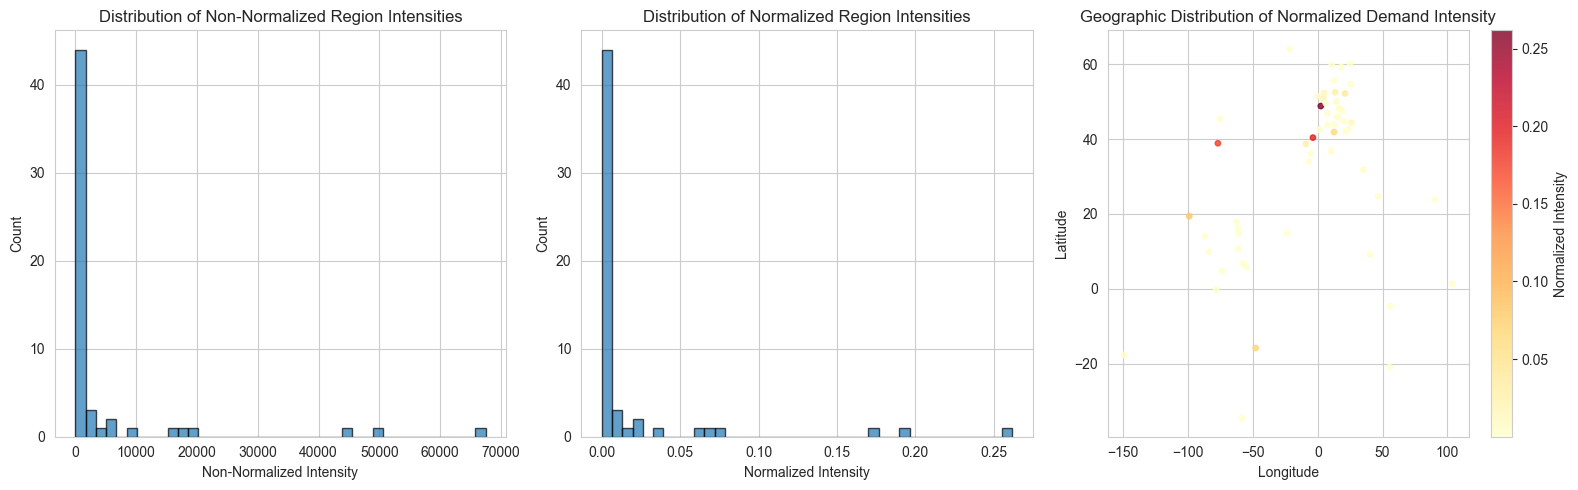

In [71]:
# VISUALIZE DEMAND INTENSITY

# Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Intensity distribution (non-normalized)
nonzero_intensities = regions_df.loc[regions_df["intensity"] > 0, "intensity"]
axes[0].hist(nonzero_intensities, bins=40, edgecolor="black", alpha=0.7)
axes[0].set_xlabel("Non-Normalized Intensity")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Non-Normalized Region Intensities")

# Intensity distribution (normalized)
nonzero_intensities = regions_df.loc[regions_df["intensity_normalized"] > 0, "intensity_normalized"]
axes[1].hist(nonzero_intensities, bins=40, edgecolor="black", alpha=0.7)
axes[1].set_xlabel("Normalized Intensity")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Normalized Region Intensities")

# Geographic intensity map (normalized)
sc = axes[2].scatter(
    regions_df["longitude"], regions_df["latitude"],
    c=regions_df["intensity_normalized"],
    cmap="YlOrRd", s=15, alpha=0.8
)
plt.colorbar(sc, ax=axes[2], label="Normalized Intensity")
axes[2].set_xlabel("Longitude")
axes[2].set_ylabel("Latitude")
axes[2].set_title("Geographic Distribution of Normalized Demand Intensity")

plt.tight_layout()
plt.show()

## 4. Fit Geographic Structure with a GMM (on the Sphere)
To capture spatial clustering in the region locations, we fit a Gaussian Mixture Model in 3-D Cartesian space (unit sphere embedding).

### 4.1 Coordinate Conversion
Each region $(\text{lat}_r, \text{lon}_r)$ is mapped to a 3-D unit vector:

$$x_r = \begin{pmatrix} \cos(\text{lat}_r) \cos(\text{lon}_r) \\ \cos(\text{lat}_r) \sin(\text{lon}_r) \\ \sin(\text{lat}_r) \end{pmatrix}$$

This mapping embeds each region’s latitude/longitude as a point on the unit sphere so that distances and clusters can be modeled in standard Euclidean $\mathbb{R}^3$ without wrap-around issues across $\pm 180^\circ$ longitude and without polar edge effects near $\pm 90^\circ$ latitude.



In [72]:
# HELPERS

def latlon_to_unit_vector(lat_deg: np.ndarray, lon_deg: np.ndarray) -> np.ndarray:
    """
    Converts latitude/longitude (degrees) to 3-D unit vectors on the sphere.

    Args:
        lat_deg (np.ndarray): Latitude in degrees.
        lon_deg (np.ndarray): Longitude in degrees.

    Returns:
        xyz (np.ndarray): Unit vectors. Shape: (n_points, 3).
    """
    
    # Convert to numpy array
    lat = np.asarray(lat_deg, dtype=float)
    lon = np.asarray(lon_deg, dtype=float)

    # Clip for numerical stability
    lat = np.clip(lat, -90.0, 90.0)
    lon = ((lon + 180.0) % 360.0) - 180.0

    # Convert lat/lon to radians
    lat_rad = np.deg2rad(lat)
    lon_rad = np.deg2rad(lon)

    # Map to 3D unit vector
    x = np.cos(lat_rad) * np.cos(lon_rad)
    y = np.cos(lat_rad) * np.sin(lon_rad)
    z = np.sin(lat_rad)
    xyz = np.column_stack([x, y, z])

    return xyz

In [73]:
# CONVERT LAT/LONG TO UNIT VECTOR

# Convert all region coordinates to unit vectors
region_coords_3d = latlon_to_unit_vector(
    regions_df["latitude"].values,
    regions_df["longitude"].values
)

# Print results
print(f"Unit vectors shape: {region_coords_3d.shape}")
print(f"Norms (should be ~1): min={np.linalg.norm(region_coords_3d, axis=1).min():.6f}, "
      f"max={np.linalg.norm(region_coords_3d, axis=1).max():.6f}")

Unit vectors shape: (57, 3)
Norms (should be ~1): min=1.000000, max=1.000000


### 4.2 Selecting the number of components $K^*$

We fit GMMs for $K \in \{2, 3, \dots, 12\}$ and choose $K^*$ using BIC (lower is better).

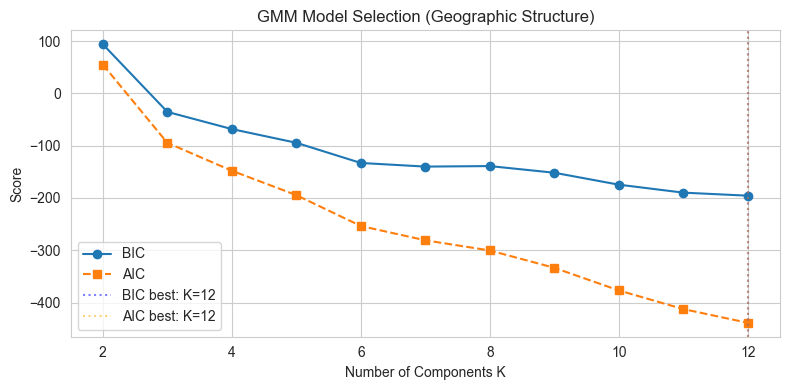

BIC selects K* = 12
AIC selects K* = 12


In [74]:
# SELECT OPTIMAL NUMBER OF COMPONENTS

# Initalize arrays and parameters
K_candidates = list(range(2, 13))
bic_scores = []
aic_scores = []

# Fit GMM for each candidate K
for K in K_candidates:
    gmm = GaussianMixture(
        n_components=K,
        random_state=SEED,
        n_init=5,
        max_iter=300,
        reg_covar=1e-6
    )
    gmm.fit(region_coords_3d)
    bic_scores.append(gmm.bic(region_coords_3d))
    aic_scores.append(gmm.aic(region_coords_3d))

# Select best K based on BIC/AIC
best_K_bic = K_candidates[int(np.argmin(bic_scores))]
best_K_aic = K_candidates[int(np.argmin(aic_scores))]

# Plots
fig, ax = plt.subplots(1, 1, figsize=(8, 4))
ax.plot(K_candidates, bic_scores, "o-", label="BIC")
ax.plot(K_candidates, aic_scores, "s--", label="AIC")
ax.axvline(best_K_bic, color="blue", ls=":", alpha=0.5, label=f"BIC best: K={best_K_bic}")
ax.axvline(best_K_aic, color="orange", ls=":", alpha=0.5, label=f"AIC best: K={best_K_aic}")
ax.set_xlabel("Number of Components K")
ax.set_ylabel("Score")
ax.set_title("GMM Model Selection (Geographic Structure)")
ax.legend()
plt.tight_layout()
plt.show()

# Print results
print(f"BIC selects K* = {best_K_bic}")
print(f"AIC selects K* = {best_K_aic}")

### 4.3 Compute geographic density scores

Using the selected $K^*$ (from BIC), compute the log-likelihood density at each real region point.

In [75]:
# GET LOG-LIKELIHOOD DENSITY FOR ALL REGIONS

# Get the best K based on BIC
K_star = best_K_bic

# Fit the GMM with the selected K
gmm_geo = GaussianMixture(
    n_components=K_star,
    random_state=SEED,
    n_init=10,
    max_iter=500,
    reg_covar=1e-6
)
gmm_geo.fit(region_coords_3d)

# Log-score each region using log-likelihood
log_density = gmm_geo.score_samples(region_coords_3d)

# Convert log-score to density and shift to avoid numerical issues
p_geo = np.exp(log_density - log_density.max())

# Store densities
regions_df["p_geo"] = p_geo

# Print results
print(f"Geographic density scores computed for {len(regions_df)} regions.")
print(f"  Min p_geo:  {p_geo.min():.6f}")
print(f"  Max p_geo:  {p_geo.max():.6f}")
print(f"  Mean p_geo: {p_geo.mean():.6f}")

Geographic density scores computed for 57 regions.
  Min p_geo:  0.000002
  Max p_geo:  1.000000
  Mean p_geo: 0.037106


In [76]:
# SAVE FITTED MODEL

# Create path
MODELS_PATH = Path("outputs/generated_models")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

# Save model
with open(MODELS_PATH / "distance_gmm_geo.pkl", "wb") as f:
    pickle.dump(gmm_geo, f)
print(f"Saved distance_gmm_geo.pkl to {MODELS_PATH}/")

Saved distance_gmm_geo.pkl to outputs\generated_models/


## 5. Sample Synthetic Regions

We compute an intensity-weighted distribution from geographic density and normalized demand intensity to derive probabilities that include both geospatial and demand-related factors:

$$p_{\text{int}}(r) = \frac{p_{\text{geo}}(r)\cdot \tilde{I}_r}{\sum_{r' \in R_{\text{real}}} p_{\text{geo}}(r')\cdot \tilde{I}_{r'}}$$

To avoid over-concentrating on a few high-weight regions, we define a uniform distribution $p_{\text{uni}}(r)=\frac{1}{|R_{\text{real}}|}$ and use the intensity-weighted distribution to nudge the uniform weights up/down:

$$p(r) = (1-\alpha)\,p_{\text{uni}}(r) + \alpha\,p_{\text{int}}(r),\quad \alpha \in [0,1]$$

We then sample $n_{\text{regions}}$ distinct regions without replacement using $p(r)$.


In [77]:
# COMPUTE SAMPLING PROBABILITIES

# Compute intensity-weighted distribution
raw_weights = regions_df["p_geo"].values * regions_df["intensity_normalized"].values
total_raw = raw_weights.sum()
if total_raw <= 0:
    raise ValueError("Total sampling weight is non-positive; check intensity and geo scores.")
p_intensity = raw_weights / total_raw

# Compute uniform distribution
n = len(regions_df)
p_uniform = np.ones(n) / n

# Mix intensity-weighted and uniform distribution (alpha: 0 = uniform, 1 = pure intensity-weighted)
alpha = 0.15 
sampling_probs = (1 - alpha) * p_uniform + alpha * p_intensity
sampling_probs /= sampling_probs.sum()

# Store sampling props
regions_df["sampling_prob"] = sampling_probs

# Print results
print("-"*55)
print(f"Sampling probability statistics:")
print("-"*55)
print(f"  Non-zero probs: {(sampling_probs > 0).sum()} / {len(sampling_probs)}")
print(f"  Sum:  {sampling_probs.sum():.6f}")
print(f"  Max:  {sampling_probs.max():.6f}")
print(f"  Min (nonzero): {sampling_probs[sampling_probs > 0].min():.8f}")
print(f"  Probability mass of top 29 regions: {np.sort(sampling_probs)[::-1][:29].sum():.8f}")

-------------------------------------------------------
Sampling probability statistics:
-------------------------------------------------------
  Non-zero probs: 57 / 57
  Sum:  1.000000
  Max:  0.122601
  Min (nonzero): 0.01491228
  Probability mass of top 29 regions: 0.58244161


In [78]:
# SAMPLE REGIONS

# New rng to play around with
rng = np.random.default_rng(232343)

# Sample n_regions distinct regions without replacement
n_nonzero = (sampling_probs > 0).sum()
if n_regions > n_nonzero:
    raise ValueError(
        f"Requested n_regions={n_regions} exceeds available non-zero-prob regions ({n_nonzero})."
    )
selected_region_indices = rng.choice(
    len(regions_df),
    size=n_regions,
    replace=False,
    p=sampling_probs
)
selected_regions_df = regions_df.iloc[selected_region_indices].copy().reset_index(drop=True)

# Print results
print(f"\nSelected {len(selected_regions_df)} regions:")
print(selected_regions_df[["regionid", "city", "country", "latitude", "longitude", "intensity", "sampling_prob"]].to_string(index=False))


Selected 10 regions:
regionid            city          country  latitude  longitude    intensity  sampling_prob
  R_0029       Reykjavik          Iceland   64.1355   -21.8954     0.258631       0.014912
  R_0010          Bogota         Colombia    4.7110   -74.0721     0.062675       0.014912
  R_0027        Budapest          Hungary   47.4979    19.0402   154.929761       0.014917
  R_0032 Luxembourg City       Luxembourg   49.6117     6.1319   226.126320       0.014921
  R_0006        Gustavia Saint Barthelemy   17.9000   -62.8333     0.394997       0.014912
  R_0043     Saint-Denis          Reunion  -20.8789    55.4481     2.489652       0.014915
  R_0030            Rome            Italy   41.9028    12.4964 16171.492878       0.015150
  R_0045        Belgrade           Serbia   44.8176    20.4569    53.515551       0.014914
  R_0022       Gibraltar        Gibraltar   36.1408    -5.3536     0.195612       0.014912
  R_0028       Jerusalem           Israel   31.7683    35.2137  1189

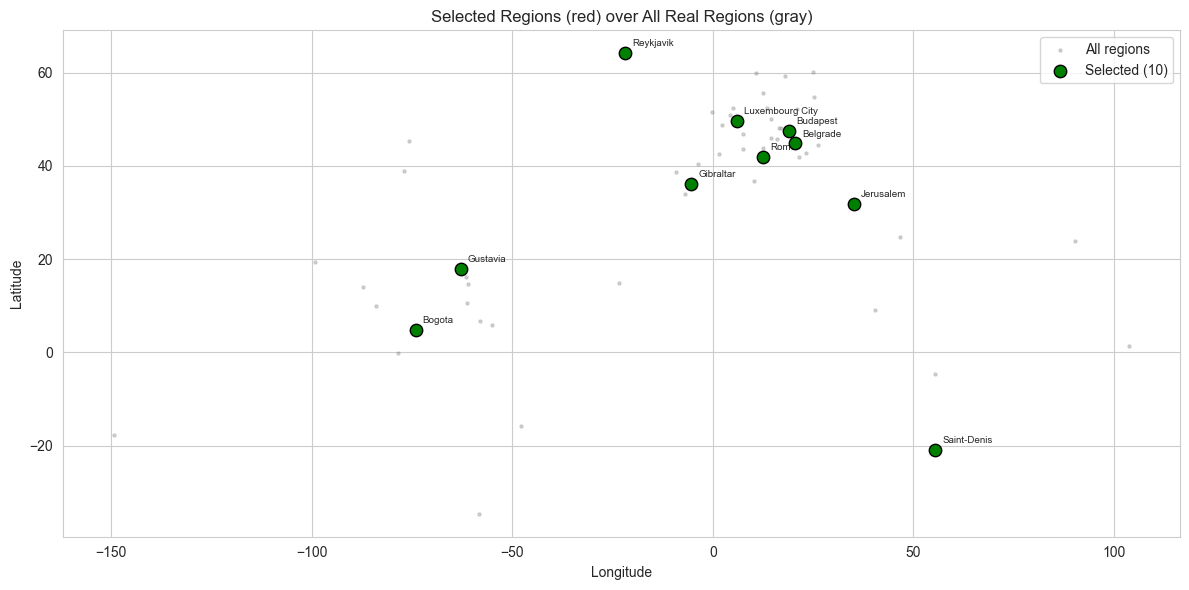

In [79]:
# VISUALIZE SELECTED REGIONS

# Plots
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.scatter(regions_df["longitude"], regions_df["latitude"], s=5, alpha=0.3, c="gray", label="All regions")
ax.scatter(selected_regions_df["longitude"], selected_regions_df["latitude"],
           s=80, c="green", edgecolors="black", zorder=5, label=f"Selected ({n_regions})")
for _, row in selected_regions_df.iterrows():
    ax.annotate(row["city"], (row["longitude"], row["latitude"]),
                fontsize=7, textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Selected Regions (red) over All Real Regions (gray)")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Select Warehouses Consistent with Selected Regions (k-Median on Real Sites)

We choose $n_{\text{warehouses}}$ from the real candidate set $W_{\text{real}}$ by minimizing demand-weighted distance:

$$\min_{W \subseteq W_{\text{real}},\, |W|=n_{\text{warehouses}}} \sum_{r \in R} \omega_r \cdot \min_{w \in W} d(w, r)$$

where $\omega_r = \tilde{I}_r / \sum_{r' \in R} \tilde{I}_{r'}$ are the region weights restricted to selected regions, and $d(w, r)$ is the haversine distance.

### 6.1 Haversine distance utility

We use the Haversine formula to compute great-circle distances in km on the Earth's surface. This avoids flat-map distortion and yields physically meaningful distances for the k-median objective.

In [80]:
# HELPERS

def haversine_distance_matrix(coords_a: np.ndarray, coords_b: np.ndarray) -> np.ndarray:
    """
    Computes pairwise haversine distances (km) between two sets of (lat, lon) points.

    Args:
        coords_a (np.ndarray): Set A coordinates. Shape: (N, 2), [latitude, longitude] in degrees.
        coords_b (np.ndarray): Set B coordinates. Shape: (M, 2), [latitude, longitude] in degrees.

    Returns:
        dist_matrix (np.ndarray): Distance matrix in km. Shape: (N, M).
    """

    lat_a = np.radians(coords_a[:, 0])[:, None]
    lon_a = np.radians(coords_a[:, 1])[:, None]
    lat_b = np.radians(coords_b[:, 0])[None, :]
    lon_b = np.radians(coords_b[:, 1])[None, :]

    dlat = lat_b - lat_a
    dlon = lon_b - lon_a

    a = np.sin(dlat / 2) ** 2 + np.cos(lat_a) * np.cos(lat_b) * np.sin(dlon / 2) ** 2
    c = 2 * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

    return EARTH_RADIUS_KM * c

In [81]:
# HAVERSINE DISTANCE TEST

# Test hf} km")aversine distance between Paris and London
test_a = np.array([[48.8566, 2.3522]])   # Paris
test_b = np.array([[51.5074, -0.1278]])   # London
print(f"Paris -> London: {haversine_distance_matrix(test_a, test_b)[0, 0]:.1f} km")

Paris -> London: 343.6 km


### 6.2 Compute warehouse-to-region distance matrix and region weights

We build the distance matrix from each real warehouse to each selected region. Region weights are obtained by re-normalizing demand intensities over the selected regions only, so the k-median objective prioritizes high-demand areas.

In [82]:
# BUILD DISTANCE MATRIX

# Get all warehouse coordinates
wh_coords = warehouses_df[["latitude", "longitude"]].values # Shape: (n_warehouses_real, 2)

# Get selected region coordinates
sel_region_coords = selected_regions_df[["latitude", "longitude"]].values # Shape: (n_regions, 2)

# Compute the distance matrix using haversine distance 
dist_wh_to_region = haversine_distance_matrix(wh_coords, sel_region_coords) # Shape: (n_warehouses_real, n_regions)

# Get region weights of selected regions and re-normalize to fit only the selected regions
sel_intensities = selected_regions_df["intensity_normalized"].values
total_sel = sel_intensities.sum()
if total_sel <= 0:
    omega_r = np.ones(n_regions) / n_regions
else:
    omega_r = sel_intensities / total_sel

# Print results
print(f"Warehouse-to-region distance matrix shape: {dist_wh_to_region.shape}")
print(f"Region weights sum: {omega_r.sum():.6f}")

Warehouse-to-region distance matrix shape: (24, 10)
Region weights sum: 1.000000


### 6.3 k-Median selection (greedy heuristic)

The demand-weighted k-median problem is NP-hard, so we use a greedy forward-selection heuristic:
1. Start with the single warehouse that minimizes the weighted cost.
2. Iteratively add the warehouse whose inclusion most reduces the total cost.
3. Repeat until $n_{\text{warehouses}}$ are selected.

This heuristic is simple, dependency-free, and typically near-optimal for moderate instance sizes.

In [27]:
# HELPERS

def greedy_k_median(
    dist_matrix: np.ndarray,
    weights: np.ndarray,
    k: int
) -> np.ndarray:
    """
    Applies greedy forward-selection to solve the demand-weighted k-median problem.

    Args:
        dist_matrix (np.ndarray): Distance matrix. Shape: (n_candidates, n_demand_points).
        weights (np.ndarray): Demand weights per demand point (should sum to 1). Shape: (n_demand_points,).
        k (int): Number of facilities to select.

    Returns:
        selected_indices (np.ndarray): Array of k selected candidate indices.
    """
    n_candidates = dist_matrix.shape[0]
    selected = []
    remaining = set(range(n_candidates))

    for _ in range(k):
        best_cost = np.inf
        best_idx = -1

        for idx in remaining:
            trial = selected + [idx]
            min_dists = dist_matrix[trial, :].min(axis=0)
            cost = np.dot(weights, min_dists)
            if cost < best_cost:
                best_cost = cost
                best_idx = idx

        selected.append(best_idx)
        remaining.discard(best_idx)

    return np.array(selected)

In [28]:
# GREEDY K-MEDIAN

# Run greedy k-median to select warehouses
selected_wh_indices = greedy_k_median(dist_wh_to_region, omega_r, n_warehouses)
selected_warehouses_df = warehouses_df.iloc[selected_wh_indices].copy().reset_index(drop=True)

# Get coordinates from selected warehouses
wh_coords_sel = selected_warehouses_df[["latitude", "longitude"]].values  # Shape: (n_warehouses, 2)

# Compute the distance matrix 
outbound_distances = haversine_distance_matrix(wh_coords_sel, sel_region_coords)

# Compute the minimum distance and the objective value
min_dists = outbound_distances.min(axis=0)
obj_value = np.dot(omega_r, min_dists)

# Print results
print(f"\nSelected {len(selected_warehouses_df)} warehouses:")
print(selected_warehouses_df[["nodeid", "latitude", "longitude", "country"]].to_string(index=False))
print(f"\nObjective (demand-weighted avg distance to nearest WH): {obj_value:.2f} km")


Selected 10 warehouses:
 nodeid  latitude  longitude                  country
N_00000 39.396429   8.420854                    Italy
N_00022 49.105009   9.348795                  Germany
N_00012 34.808740 -76.363180 United States of America
N_00023 62.304889   5.469595                   Norway
N_00019 33.835252  -4.985797                  Morocco
N_00018 21.411219 -97.388960                   Mexico
N_00010 54.460378  12.547585                  Germany
N_00016 40.767877  -3.591687                    Spain
N_00003 50.151751  -5.754934           United Kingdom
N_00015 43.026825  -9.392884                    Spain

Objective (demand-weighted avg distance to nearest WH): 586.44 km


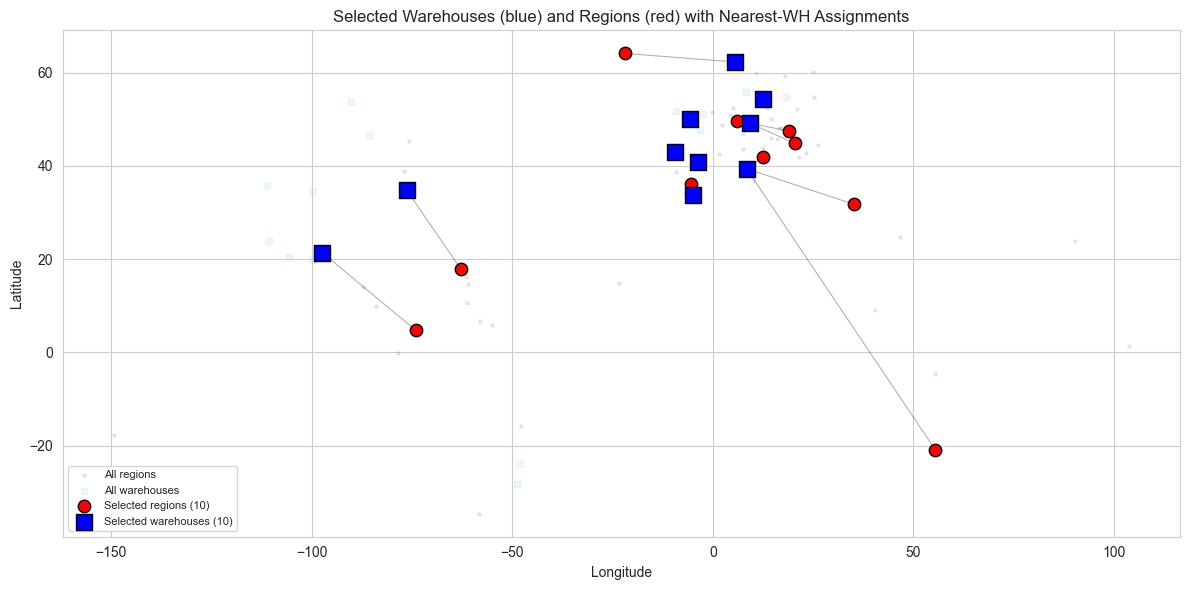

In [29]:
# VISUALIZE WAREHOUSES AND REGIONS

# Plots
fig, ax = plt.subplots(1, 1, figsize=(12, 6))
ax.scatter(regions_df["longitude"], regions_df["latitude"], s=5, alpha=0.15, c="gray", label="All regions")
ax.scatter(warehouses_df["longitude"], warehouses_df["latitude"], s=15, alpha=0.2, c="lightblue", marker="s", label="All warehouses")
ax.scatter(selected_regions_df["longitude"], selected_regions_df["latitude"],
           s=80, c="red", edgecolors="black", zorder=5, label=f"Selected regions ({n_regions})")
ax.scatter(selected_warehouses_df["longitude"], selected_warehouses_df["latitude"],
           s=120, c="blue", marker="s", edgecolors="black", zorder=5, label=f"Selected warehouses ({n_warehouses})")
for i, r_row in selected_regions_df.iterrows():
    nearest_wh_idx = np.argmin(outbound_distances[:, i])
    wh_row = selected_warehouses_df.iloc[nearest_wh_idx]
    ax.plot([r_row["longitude"], wh_row["longitude"]],
            [r_row["latitude"], wh_row["latitude"]],
            "k-", alpha=0.3, lw=0.8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Selected Warehouses (blue) and Regions (red) with Nearest-WH Assignments")
ax.legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

## 7. Select Suppliers

For each warehouse and each selected SKU, we model the inbound flow as the distance to the closest supplier that can supply that SKU. We follow these steps to select suppliers:

1. Use the selected $n_{\text{skus}}$ SKUs.
2. Keep only suppliers that sell at least one of the selected SKUs.
3. For each (warehouse, SKU) pair, compute the distance to the closest feasible supplier.

We use the `selected_sku_ids` from Section 1.4 and build a mapping from each selected SKU to the list of suppliers that sell it and then restrict the supplier set to those that sell at least one selected SKU. This ensures every selected SKU has at least one feasible supplier.

In [30]:
# BUILD SKU-SUPPLIER MAPPING

# Build SKU-supplier mapping
sku_supplier_map = (
    skus_per_supplier_df
    .groupby("itemid")["supplierid"]
    .apply(list)
    .to_dict()
)

# Restrict mapping to selected SKUs
selected_sku_suppliers = {}
all_selected_supplier_ids = set()
for sku_id in selected_sku_ids:
    suppliers = sku_supplier_map.get(sku_id, [])
    selected_sku_suppliers[sku_id] = suppliers
    all_selected_supplier_ids.update(suppliers)

# Filter to only suppliers that have at least one selected SKU
selected_suppliers_df = suppliers_df[suppliers_df["supplierid"].isin(all_selected_supplier_ids)].copy().reset_index(drop=True)

# Print results
print(f"\nSuppliers with at least one selected SKU: {len(selected_suppliers_df)}")

# Verify that every selected SKU has at least one supplier
orphan_skus = [s for s in selected_sku_ids if len(selected_sku_suppliers.get(s, [])) == 0]
if orphan_skus:
    print(f"  WARNING: {len(orphan_skus)} SKUs have no suppliers in the raw data.")
else:
    print(f"All selected SKUs have at least one feasible supplier.")


Suppliers with at least one selected SKU: 12
All selected SKUs have at least one feasible supplier.


In [31]:
# BUILD WAREHOUSE-SUPPLIER MAPPING & COMPUTE DISTANCES

# Build supplier coordinate lookup
supplier_coord_map = suppliers_df.set_index("supplierid")[["latitude", "longitude"]].to_dict(orient="index")

# For each (warehouse, sku) pair, find the distance to the closest supplier for that SKU
inbound_distances = np.full((n_warehouses, n_skus), np.inf) # Shape: (n_warehouses, n_skus)
for sku_idx, sku_id in enumerate(selected_sku_ids):
    feasible_suppliers = selected_sku_suppliers.get(sku_id, [])
    if not feasible_suppliers:
        continue
    sup_coords = np.array([
        [supplier_coord_map[sid]["latitude"], supplier_coord_map[sid]["longitude"]]
        for sid in feasible_suppliers
        if sid in supplier_coord_map
    ])
    if len(sup_coords) == 0:
        continue
    dists = haversine_distance_matrix(wh_coords_sel, sup_coords)
    inbound_distances[:, sku_idx] = dists.min(axis=1)

# Check for any remaining inf values (SKUs with no suppliers)
n_inf = np.isinf(inbound_distances).sum()
print(f"Inbound distance matrix shape: {inbound_distances.shape}")
print(f"  Inf entries (no supplier found): {n_inf}")
if n_inf == 0:
    print(f"  Min distance:  {inbound_distances.min():.2f} km")
    print(f"  Max distance:  {inbound_distances.max():.2f} km")
    print(f"  Mean distance: {inbound_distances.mean():.2f} km")

Inbound distance matrix shape: (10, 10)
  Inf entries (no supplier found): 0
  Min distance:  282.27 km
  Max distance:  10111.51 km
  Mean distance: 3048.40 km


## 8. Final Distances

We compute and display the final distance tables:

- Outbound lanes (warehouse → region): $d(w, r)$ for all $w \in W, r \in R$
- Inbound lanes (supplier → warehouse per SKU): $d(w, \text{sku})$ for all $w \in W, \text{sku} \in \text{SKU}$

In [32]:
# OUTBOUND DISTANCE TABLE

# Compute the outbound distance matrix 
outbound_df = pd.DataFrame(
    outbound_distances,
    index=[f"WH_{i}" for i in range(n_warehouses)],
    columns=[f"R_{i}" for i in range(n_regions)]
) # Shape: (n_warehouses, n_regions)

# Print results
print("="*55)
print("Outbound Distance Table (WH -> Region, km)")
print("="*55)
print(outbound_df.round(1).to_string())
print(f"\nShape: {outbound_distances.shape}")
print(f"Min: {outbound_distances.min():.1f} km")
print(f"Max: {outbound_distances.max():.1f} km")
print(f"Mean: {outbound_distances.mean():.1f} km")

Outbound Distance Table (WH -> Region, km)
         R_0     R_1      R_2     R_3     R_4      R_5     R_6      R_7     R_8      R_9
WH_0  3385.2  9030.6   1241.3  1150.2  7165.8   8292.4   442.5   1159.8  1262.2   2555.7
WH_1  2493.8  9133.0    738.2   239.7  7225.2   9017.7   837.4    967.1  1870.7   2890.8
WH_2  4869.8  3355.0   7602.4  6640.2  2308.2  15081.8  7431.5   7843.4  6278.7   9728.2
WH_3  1375.0  9004.4   1852.4  1412.0  7135.7  10238.9  2315.6   2169.7  3004.3   4000.5
WH_4  3562.1  7789.0   2515.1  1977.2  5973.0   8825.3  1772.5   2490.9   258.5   3740.5
WH_5  7174.1  3125.7  10076.5  9131.9  3632.4  17201.0  9955.8  10333.6  8798.7  12242.0
WH_6  2193.3  9363.1    896.9   694.6  7457.2   9319.2  1396.3   1212.4  2456.3   3093.4
WH_7  2855.0  8027.4   1946.1  1241.9  6149.1   9168.5  1347.1   2005.3   536.9   3587.9
WH_8  1822.9  8073.1   1830.2   852.9  6163.9   9913.4  1674.4   2044.9  1558.3   3931.8
WH_9  2477.5  7609.1   2266.6  1395.1  5713.7   9706.7  1794.8   23

In [33]:
#INBOUND DISTANCE TABLE

# Compute the inbound distance matrix
inbound_df = pd.DataFrame(
    inbound_distances,
    index=[f"WH_{i}" for i in range(n_warehouses)],
    columns=[f"SKU_{i}" for i in range(n_skus)]
) # Shape: (n_warehouses, n_skus)

print("="*55)
print("Inbound Distance Table (WH -> closest supplier for SKU, km)")
print("="*55)
print(f"Shape: {inbound_distances.shape}")
print(f"Min: {inbound_distances.min():.1f} km")
print(f"Max: {inbound_distances.max():.1f} km")
print(f"Mean: {inbound_distances.mean():.1f} km")
print(f"\nFirst 10 columns:")
print(inbound_df.iloc[:, :10].round(1).to_string())

Inbound Distance Table (WH -> closest supplier for SKU, km)
Shape: (10, 10)
Min: 282.3 km
Max: 10111.5 km
Mean: 3048.4 km

First 10 columns:
       SKU_0   SKU_1   SKU_2   SKU_3   SKU_4   SKU_5   SKU_6    SKU_7   SKU_8   SKU_9
WH_0   823.2   532.0  9009.8  1607.7   550.3   574.9   713.8   1441.9  1522.3   582.3
WH_1  1103.1   940.0  8511.3   666.7   805.6   916.6   817.9    845.7   645.9   982.5
WH_2  6423.3  6718.9  1878.9  7225.7  6696.3  6680.2  6572.0   7656.0  7309.9  6664.9
WH_3  2285.5  2275.5  7615.8  1284.5  1532.7  2235.1  1755.4   1779.7  1406.9  2291.7
WH_4   990.6  1138.6  8258.3  2724.2  1085.2  1155.0  1256.6   2706.9  2676.0  1089.1
WH_5  8957.5  9252.0   982.3  9656.7  9230.0  9212.7  9101.6  10111.5  9750.7  9198.4
WH_6  1683.9  1562.0  8389.8   368.9   639.1  1533.9  1043.0    854.5   475.2  1598.8
WH_7   282.3   567.5  8038.6  2040.5   523.0   552.5   569.8   2118.8  2012.7   503.3
WH_8   978.2  1140.5  7481.2  1603.8  1150.8  1091.7   928.9   1923.8  1643.8  1117.3

## 9. Testing & Validation

We validate the region, warehouse, and supplier selection by following these steps:

1. Comparing selected region distribution against the overall intensity distribution.
2. Verifying warehouse coverage by checking if each selected region is reasonably close to at least one warehouse.
3. Comparing inbound and outbound distance distributions to real-world distances.
4. Visualizing all selections on a single map.

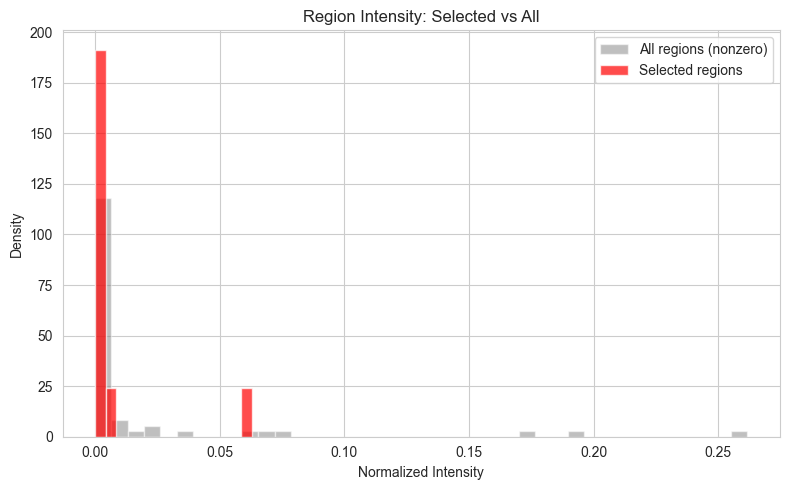

In [34]:
# REGION INTENSITY OF SELECTED VS ALL REGIONS

# Plots
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
all_nonzero = regions_df.loc[regions_df["intensity"] > 0, "intensity_normalized"]
sel_normalized = selected_regions_df["intensity_normalized"]
ax.hist(all_nonzero, bins=40, alpha=0.5, label="All regions (nonzero)", density=True, color="gray")
ax.hist(sel_normalized, bins=15, alpha=0.7, label="Selected regions", density=True, color="red")
ax.set_xlabel("Normalized Intensity")
ax.set_ylabel("Density")
ax.set_title("Region Intensity: Selected vs All")
ax.legend()
plt.tight_layout()
plt.show()

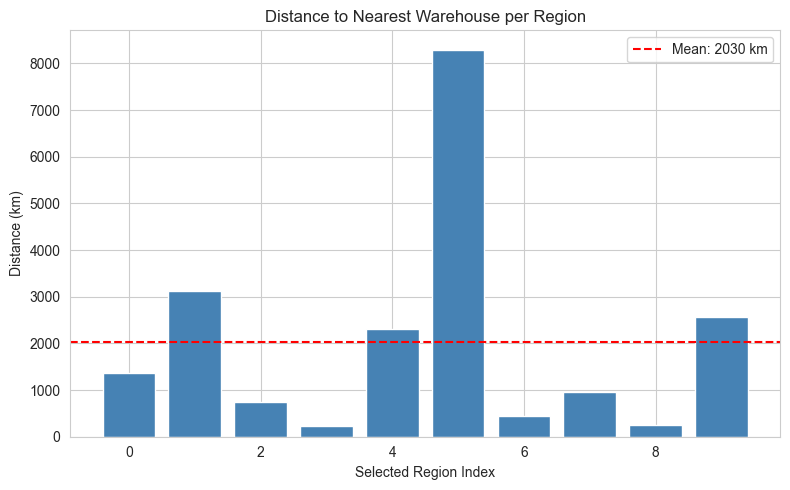

In [35]:
# DISTANCE FROM EACH REGION TO ITS NEAREST WAREHOUSE

# Plots
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
nearest_wh_distances = outbound_distances.min(axis=0)
ax.bar(range(n_regions), nearest_wh_distances, color="steelblue")
ax.set_xlabel("Selected Region Index")
ax.set_ylabel("Distance (km)")
ax.set_title("Distance to Nearest Warehouse per Region")
ax.axhline(y=nearest_wh_distances.mean(), color="red", ls="--", label=f"Mean: {nearest_wh_distances.mean():.0f} km")
ax.legend()
plt.tight_layout()
plt.show()

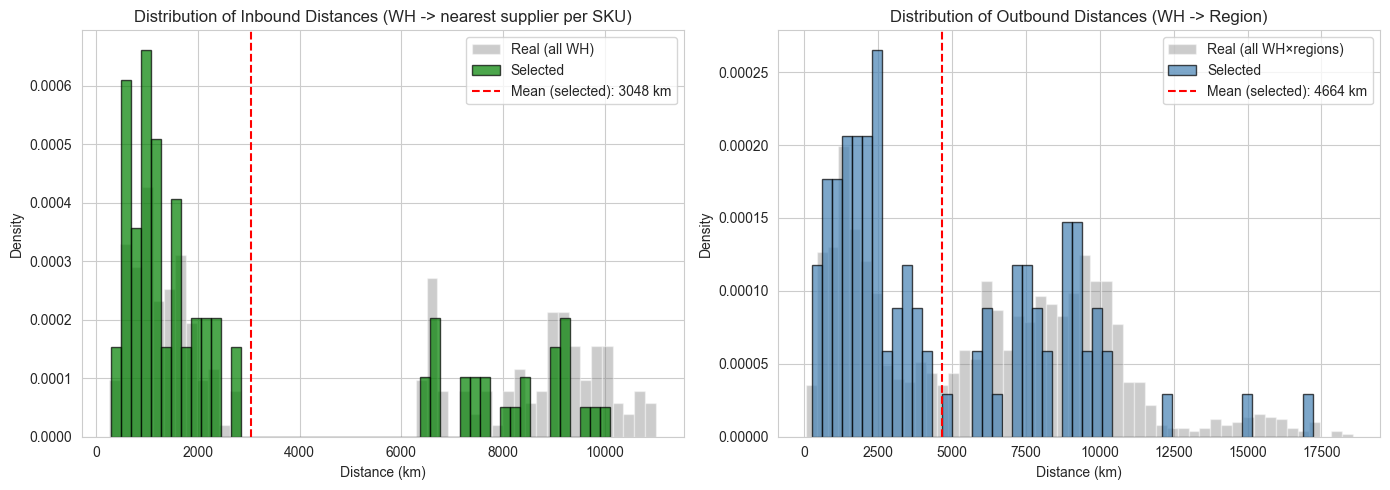

In [36]:
# INBOUND & OUTBOUND DISTANCE DISTRIBUTION

# Compute real distance distributions for comparison
real_wh_coords = warehouses_df[["latitude", "longitude"]].values
real_region_coords = regions_df[["latitude", "longitude"]].values
real_outbound = haversine_distance_matrix(real_wh_coords, real_region_coords).flatten()
real_inbound = np.full((len(warehouses_df), n_skus), np.inf)
for sku_idx, sku_id in enumerate(selected_sku_ids):
    feasible_suppliers = selected_sku_suppliers.get(sku_id, [])
    if not feasible_suppliers:
        continue
    sup_coords = np.array([
        [supplier_coord_map[sid]["latitude"], supplier_coord_map[sid]["longitude"]]
        for sid in feasible_suppliers if sid in supplier_coord_map
    ])
    if len(sup_coords) == 0:
        continue
    dists = haversine_distance_matrix(real_wh_coords, sup_coords)
    real_inbound[:, sku_idx] = dists.min(axis=1)
finite_real_inbound = real_inbound[np.isfinite(real_inbound)]

# Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
finite_inbound = inbound_distances[np.isfinite(inbound_distances)]
axes[0].hist(finite_real_inbound, bins=50, alpha=0.4, color="gray", density=True, label="Real (all WH)")
axes[0].hist(finite_inbound, bins=50, edgecolor="black", alpha=0.7, color="green", density=True, label="Selected")
axes[0].set_xlabel("Distance (km)")
axes[0].set_ylabel("Density")
axes[0].set_title("Distribution of Inbound Distances (WH -> nearest supplier per SKU)")
axes[0].axvline(finite_inbound.mean(), color="red", ls="--", label=f"Mean (selected): {finite_inbound.mean():.0f} km")
axes[0].legend()
axes[1].hist(real_outbound, bins=50, alpha=0.4, color="gray", density=True, label="Real (all WH×regions)")
axes[1].hist(outbound_distances.flatten(), bins=50, edgecolor="black", alpha=0.7, color="steelblue", density=True, label="Selected")
axes[1].set_xlabel("Distance (km)")
axes[1].set_ylabel("Density")
axes[1].set_title("Distribution of Outbound Distances (WH -> Region)")
axes[1].axvline(outbound_distances.mean(), color="red", ls="--", label=f"Mean (selected): {outbound_distances.mean():.0f} km")
axes[1].legend()

plt.tight_layout()
plt.show()

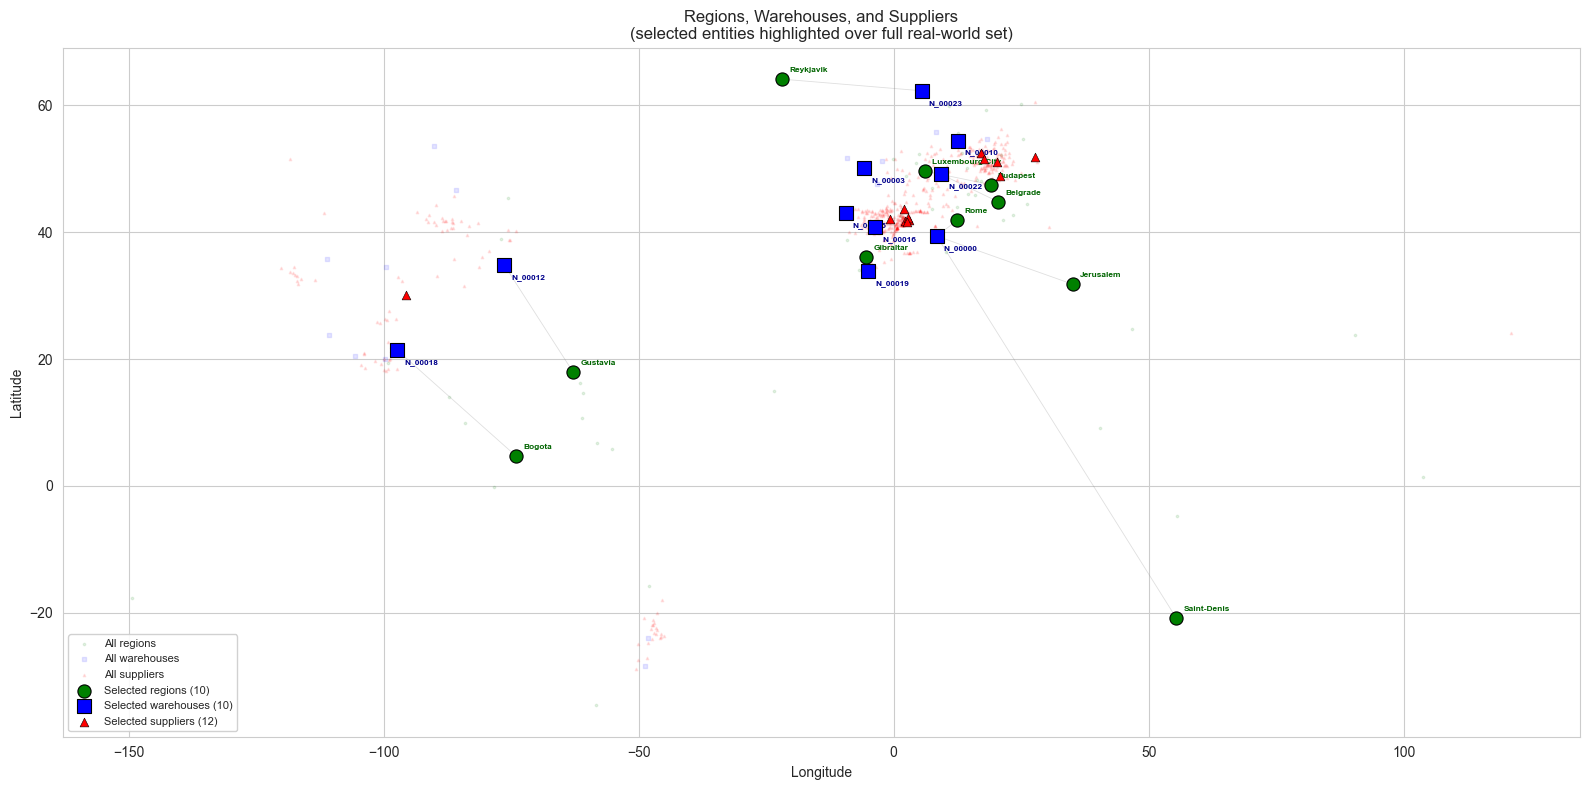

In [37]:
# VISUALIZE ALL SELECTIONS ON A SINGLE MAP

# Plots
fig, ax = plt.subplots(1, 1, figsize=(16, 8))

# All real entities (faded)
ax.scatter(regions_df["longitude"], regions_df["latitude"],
           s=3, alpha=0.1, c="green", label="All regions")
ax.scatter(warehouses_df["longitude"], warehouses_df["latitude"],
           s=12, alpha=0.1, c="blue", marker="s", label="All warehouses")
ax.scatter(suppliers_df["longitude"], suppliers_df["latitude"],
           s=3, alpha=0.1, c="red", marker="^", label="All suppliers")

# Selected entities (highlighted)
ax.scatter(selected_regions_df["longitude"], selected_regions_df["latitude"],
           s=90, c="green", edgecolors="black", linewidths=0.8, zorder=10,
           label=f"Selected regions ({n_regions})")

ax.scatter(selected_warehouses_df["longitude"], selected_warehouses_df["latitude"],
           s=90, c="blue", marker="s", edgecolors="black", linewidths=0.8, zorder=10,
           label=f"Selected warehouses ({n_warehouses})")

ax.scatter(selected_suppliers_df["longitude"], selected_suppliers_df["latitude"],
           s=40, c="red", marker="^", edgecolors="black", linewidths=0.4, zorder=8,
           label=f"Selected suppliers ({len(selected_suppliers_df)})")

# Draw outbound lines (warehouse -> nearest region)
for i, r_row in selected_regions_df.iterrows():
    nearest_wh_idx = np.argmin(outbound_distances[:, i])
    wh_row = selected_warehouses_df.iloc[nearest_wh_idx]
    ax.plot([r_row["longitude"], wh_row["longitude"]],
            [r_row["latitude"], wh_row["latitude"]],
            "gray", alpha=0.25, lw=0.6)

# Annotate selected regions
for _, row in selected_regions_df.iterrows():
    ax.annotate(row["city"], (row["longitude"], row["latitude"]),
                fontsize=6, textcoords="offset points", xytext=(5, 5),
                color="darkgreen", fontweight="bold")

# Annotate selected warehouses
for _, row in selected_warehouses_df.iterrows():
    ax.annotate(row["nodeid"], (row["longitude"], row["latitude"]),
                fontsize=6, textcoords="offset points", xytext=(5, -10),
                color="darkblue", fontweight="bold")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Regions, Warehouses, and Suppliers\n"
             "(selected entities highlighted over full real-world set)")
ax.legend(loc="lower left", fontsize=8, framealpha=0.9)
plt.tight_layout()
plt.show()

## 10. Summary statistics

We finally report an overview of the distance selection output that includes selection counts, GMM and k-median parameters, and min/max/mean for outbound and inbound distance matrices.

In [38]:
print("=" * 60)
print("DISTANCE GENERATION PIPELINE — SUMMARY")
print("=" * 60)
print(f"  Selected regions:    {n_regions}")
print(f"  Selected warehouses: {n_warehouses}")
print(f"  Selected SKUs:       {n_skus}")
print(f"  Selected suppliers:  {len(selected_suppliers_df)}")
print()
print(f"  GMM components (K*):             {K_star}")
print(f"  k-median objective:              {obj_value:.2f} km")
print()
print(f"  Outbound distance matrix shape:  {outbound_distances.shape}")
print(f"    Min:  {outbound_distances.min():.1f} km")
print(f"    Max:  {outbound_distances.max():.1f} km")
print(f"    Mean: {outbound_distances.mean():.1f} km")
print()
print(f"  Inbound distance matrix shape:   {inbound_distances.shape}")
finite = inbound_distances[np.isfinite(inbound_distances)]
if len(finite) > 0:
    print(f"    Min:  {finite.min():.1f} km")
    print(f"    Max:  {finite.max():.1f} km")
    print(f"    Mean: {finite.mean():.1f} km")
else:
    print(f"    No finite inbound distances found.")
print(f"    Inf entries: {np.isinf(inbound_distances).sum()}")
print("=" * 60)

DISTANCE GENERATION PIPELINE — SUMMARY
  Selected regions:    10
  Selected warehouses: 10
  Selected SKUs:       10
  Selected suppliers:  12

  GMM components (K*):             12
  k-median objective:              586.44 km

  Outbound distance matrix shape:  (10, 10)
    Min:  239.7 km
    Max:  17201.0 km
    Mean: 4664.1 km

  Inbound distance matrix shape:   (10, 10)
    Min:  282.3 km
    Max:  10111.5 km
    Mean: 3048.4 km
    Inf entries: 0


## 11. Save Outputs for Downstream Pipelines

Save the distance matrices and selected SKU indices so they can be loaded by `cost_generator.ipynb` and other downstream notebooks.

In [39]:
# SAVE OUTPUTS

# Save outputs to the output path
OUTPUTS_PATH = Path("outputs/intermediate")
OUTPUTS_PATH.mkdir(parents=True, exist_ok=True)

out_path = OUTPUTS_PATH / f"distances_n{n_regions}_w{n_warehouses}_s{n_skus}.npz"
np.savez(
    out_path,
    outbound_distances=outbound_distances,
    inbound_distances=inbound_distances,
    sku_indices=selected_sku_indices,
)

# Print results
print(f"Saved to {out_path}")
print(f"  outbound_distances: {outbound_distances.shape}")
print(f"  inbound_distances:  {inbound_distances.shape}")
print(f"  sku_indices:        {len(selected_sku_indices)} SKUs")

Saved to outputs\intermediate\distances_n10_w10_s10.npz
  outbound_distances: (10, 10)
  inbound_distances:  (10, 10)
  sku_indices:        10 SKUs
